
📊 Training model for: Scope 1 Emissions


/opt/anaconda3/envs/Dissertation/lib/python3.10/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['net_income']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


R²:    0.9772810926076747
MAE:   91128.07022922774
RMSE:  415382.400525573


/opt/anaconda3/envs/Dissertation/lib/python3.10/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['net_income']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


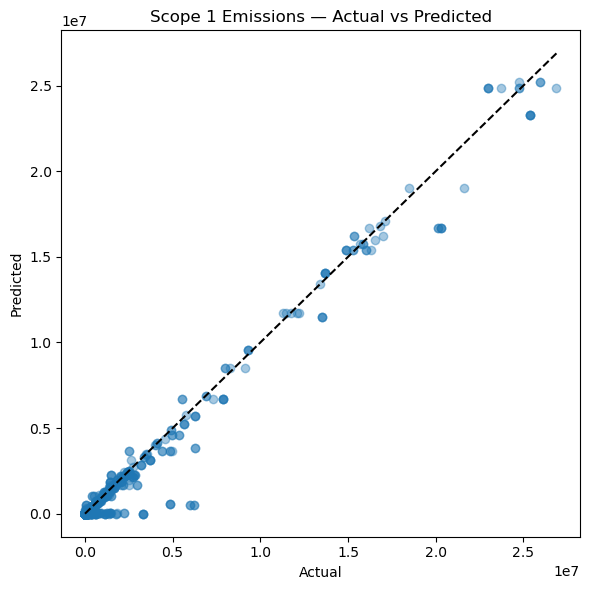

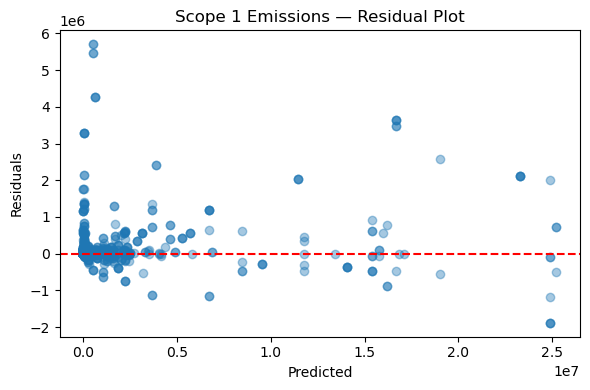

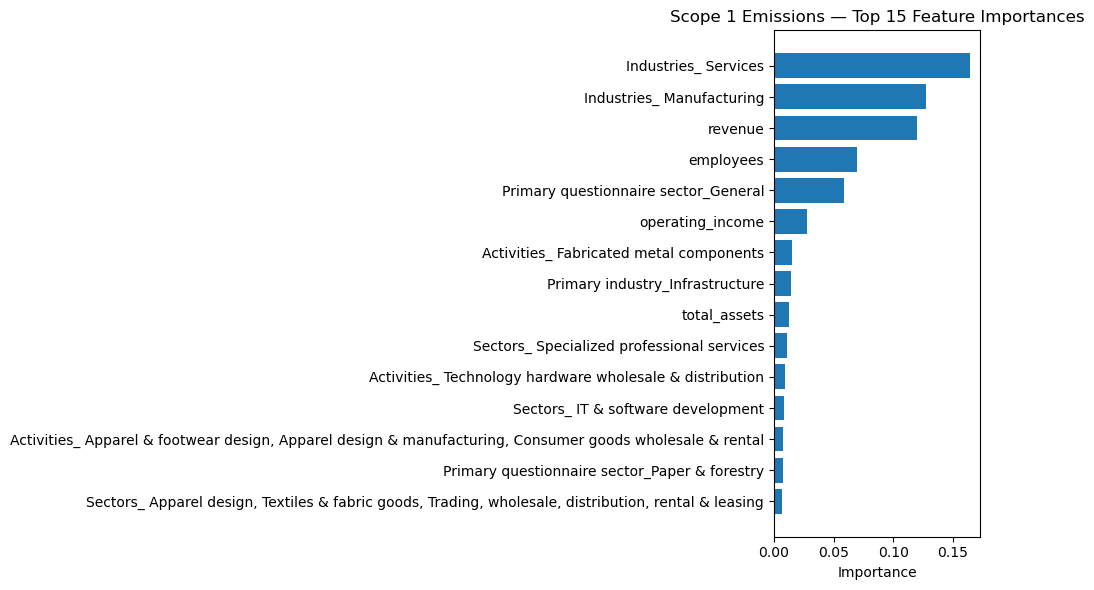

📁 Predictions saved to: scope_1_emissions_predictions.FINAL.csv
✅ Model saved as: scope_1_emissions_model.FINAL.pkl

📊 Training model for: Scope 2 Emissions
R²:    0.8862627032369008
MAE:   23122.113380153914
RMSE:  171421.47777955545


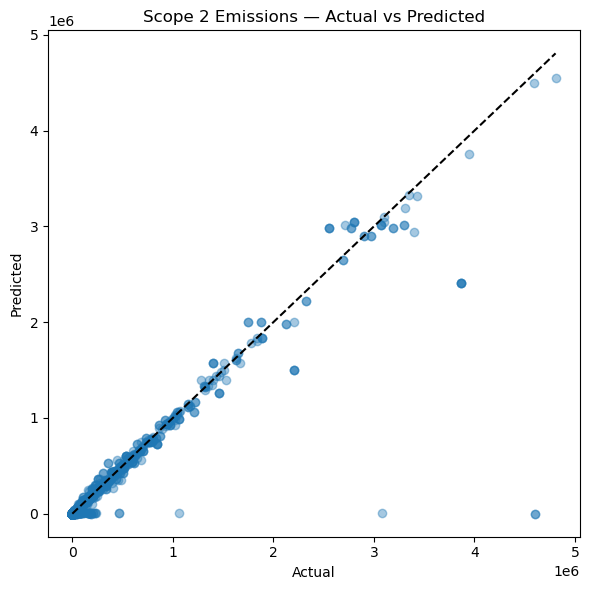

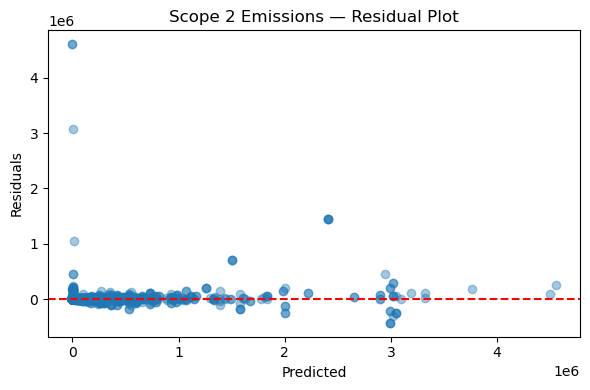

/var/folders/gw/vnsb934j7fvdc3rjq0d035h00000gn/T/ipykernel_49056/3078766509.py:141: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


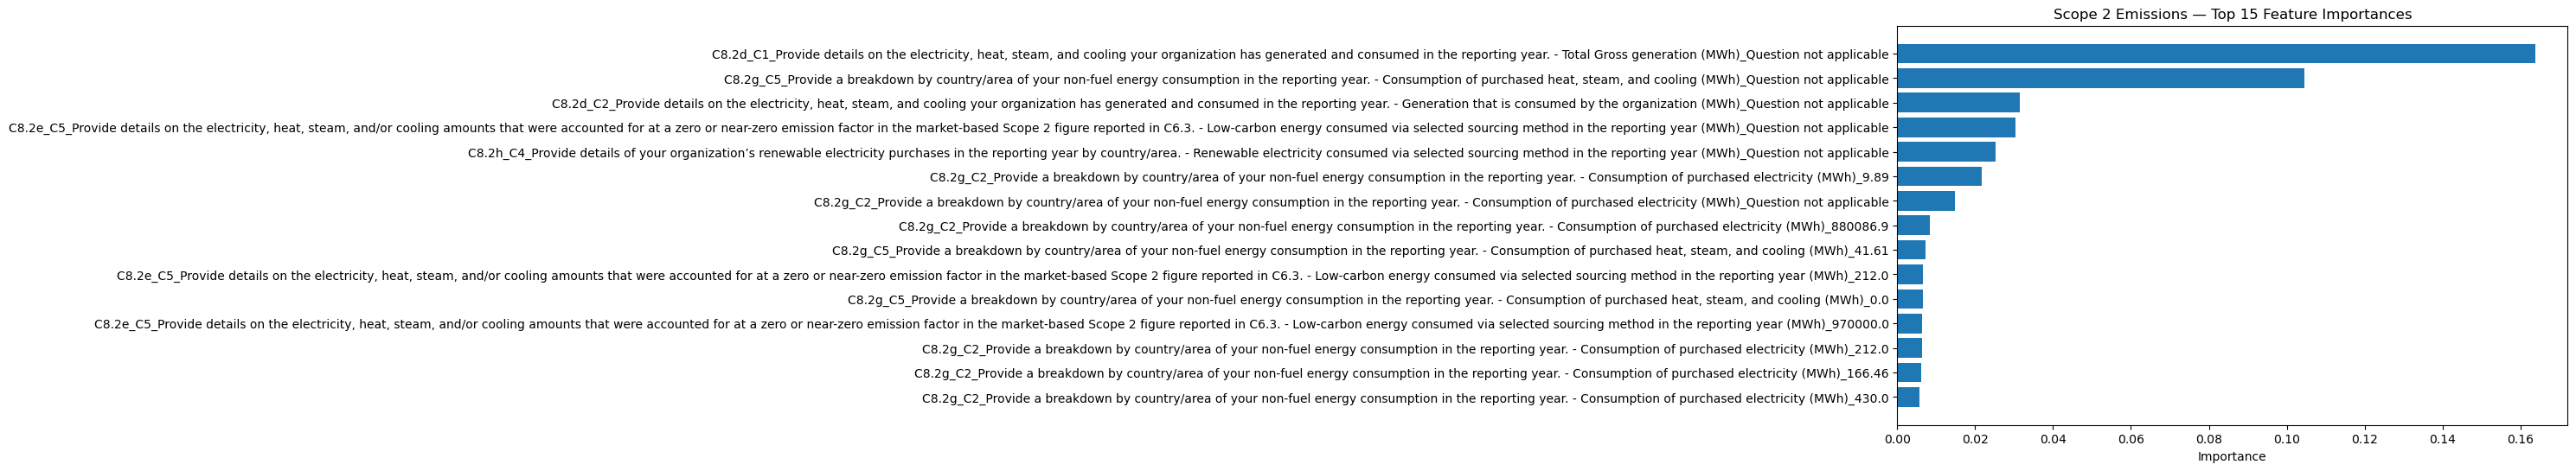

📁 Predictions saved to: scope_2_emissions_predictions.FINAL.csv
✅ Model saved as: scope_2_emissions_model.FINAL.pkl


In [17]:
# ============================================================
# Scope 1 & 2 Emissions — Clean Predict & Merge Pipeline
# ------------------------------------------------------------
# Input :
#   - cdp_and_wikidata_for_regression.csv            (features + targets)
#   - wikidata_financial_features_with_industry.csv  (for name matching)
#   - [optional pre-trained models]
#       • scope_1_emissions_model.FINAL.pkl
#       • scope_2_emissions_model.FINAL.pkl
#
# Output:
#   - scope_1_predictions.FINAL.csv
#   - scope_2_predictions.FINAL.csv
#   - combined_scope_1+2_predictions.csv               (actuals + predictions)
#   - merged_scope_1+2_predictions_matched.csv         (with matched_stock via fuzzy matching)
#
# Notes:
#   - All regression *training / evaluation / plots* are kept but COMMENTED OUT
#     to keep the notebook light for evaluators. Un-comment to re-train.
#   - If no pre-trained models exist, simply un-comment the training block,
#     run it once, then re-run the prediction block.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Load dataset ===
df = pd.read_csv("cdp_and_wikidata_for_regression.csv")

# === Ensure numeric targets ===
df["Scope 1 Emissions"] = pd.to_numeric(df["Scope 1 Emissions"], errors="coerce")
df["Scope 2 Emissions"] = pd.to_numeric(df["Scope 2 Emissions"], errors="coerce")

# === Feature subsets ===
scope1_features = [
    "Activities", "Sectors", "Industries",
    "Primary activity", "Primary sector", "Primary industry", "Primary questionnaire sector",
    "revenue", "operating_income", "net_income", "total_assets", "total_equity", "employees"
]

scope2_features = [
    "C8.2d_C1_Provide details on the electricity, heat, steam, and cooling your organization has generated and consumed in the reporting year. - Total Gross generation (MWh)",
    "C8.2d_C2_Provide details on the electricity, heat, steam, and cooling your organization has generated and consumed in the reporting year. - Generation that is consumed by the organization (MWh)",
    "C8.2e_C5_Provide details on the electricity, heat, steam, and/or cooling amounts that were accounted for at a zero or near-zero emission factor in the market-based Scope 2 figure reported in C6.3. - Low-carbon energy consumed via selected sourcing method in the reporting year (MWh)",
    "C8.2g_C2_Provide a breakdown by country/area of your non-fuel energy consumption in the reporting year. - Consumption of purchased electricity (MWh)",
    "C8.2g_C5_Provide a breakdown by country/area of your non-fuel energy consumption in the reporting year. - Consumption of purchased heat, steam, and cooling (MWh)",
    "C8.2h_C4_Provide details of your organization’s renewable electricity purchases in the reporting year by country/area. - Renewable electricity consumed via selected sourcing method in the reporting year (MWh)"
]

target_feature_map = {
    "Scope 1 Emissions": scope1_features,
    "Scope 2 Emissions": scope2_features
}

# === Helper function for robust feature name extraction ===
def get_transformed_feature_names(preprocessor: ColumnTransformer, input_features: list[str]) -> list[str]:
    output_features = []
    for name, transformer, features in preprocessor.transformers_:
        if name == 'remainder':
            continue
        if isinstance(transformer, Pipeline):
            step = transformer.steps[-1][1]
        else:
            step = transformer
        try:
            names = step.get_feature_names_out(features)
        except:
            names = features
        output_features.extend(names)
    return output_features

# === Train models per target ===
for target_col, features in target_feature_map.items():
    print(f"\n📊 Training model for: {target_col}")

    df_model = df.dropna(subset=[target_col])
    
    # === Outlier filtering and log transform for both Scope 1 and 2 ===
    q99 = df_model[target_col].quantile(0.99)
    df_model = df_model[df_model[target_col] <= q99]

    X = df_model[features]
    y = df_model[target_col]

    categorical = X.select_dtypes(include=["object"]).columns.tolist()
    numerical = X.select_dtypes(include=["number"]).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numerical),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical)
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
    ])

    # === Log transform for both Scope 1 and 2 ===
    y_train_log = np.log1p(y_train)
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # === Evaluation ===
    print("R²:   ", r2_score(y_test, y_pred))
    print("MAE:  ", mean_absolute_error(y_test, y_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

    # === Plot: Actual vs Predicted ===
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{target_col} — Actual vs Predicted")
    plt.tight_layout()
    plt.show()

    # === Plot: Residuals ===
    residuals = y_test - y_pred
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"{target_col} — Residual Plot")
    plt.tight_layout()
    plt.show()

    # === Feature importances ===
    preprocessor_fitted = model.named_steps["preprocessor"]
    feature_names = get_transformed_feature_names(preprocessor_fitted, features)

    importances = model.named_steps["regressor"].feature_importances_
    assert len(feature_names) == len(importances), f"⚠ Mismatch: {len(feature_names)} vs {len(importances)} importances"

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    # === Plot Top 15 Feature Importances ===
    plt.figure(figsize=(10, 6))
    plt.barh(fi_df["Feature"][:15][::-1], fi_df["Importance"][:15][::-1])
    plt.xlabel("Importance")
    plt.title(f"{target_col} — Top 15 Feature Importances")
    plt.tight_layout()
    plt.show()

    # === Store predictions with metadata ===
    df_results = pd.DataFrame({
        "Organization": X_test.index.map(lambda i: df_model.loc[i].get("Organization", f"Row_{i}")),
        "Actual": y_test.values,
        "Predicted": y_pred,
        "Residual": y_test.values - y_pred,
        "Target": target_col
    })
    
    # Save predictions
    csv_name = f"{target_col.replace(' ', '_').lower()}_predictions.FINAL.csv"
    df_results.to_csv(csv_name, index=False)
    print(f"📁 Predictions saved to: {csv_name}")
    
    # Save model
    model_name = f"{target_col.replace(' ', '_').lower()}_model.FINAL.pkl"
    joblib.dump(model, model_name)
    print(f"✅ Model saved as: {model_name}")
